In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import spacy
import os

In [3]:
# Download NLTK data (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...


True

In [4]:
# Sample raw text
sample_text = "The government is investing heavily in clean energy. However, citizens are concerned about affordable energy prices during the winter months!"

In [6]:
# Tokenization and Lowercasing
tokens = word_tokenize(sample_text.lower())
print("Tokens:", tokens)

Tokens: ['the', 'government', 'is', 'investing', 'heavily', 'in', 'clean', 'energy', '.', 'however', ',', 'citizens', 'are', 'concerned', 'about', 'affordable', 'energy', 'prices', 'during', 'the', 'winter', 'months', '!']


In [7]:
# Stop-word and Punctuation Removal
stop_words = set(stopwords.words('english'))
clean_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
print("Clean Tokens:", clean_tokens)


Clean Tokens: ['government', 'investing', 'heavily', 'clean', 'energy', 'however', 'citizens', 'concerned', 'affordable', 'energy', 'prices', 'winter', 'months']


In [8]:
# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in clean_tokens]
print("Lemmatized Tokens:", lemmatized_tokens)

Lemmatized Tokens: ['government', 'investing', 'heavily', 'clean', 'energy', 'however', 'citizen', 'concerned', 'affordable', 'energy', 'price', 'winter', 'month']


In [9]:
#Stemming 
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in clean_tokens]
print("Stemmed Tokens:", stemmed_tokens)

Stemmed Tokens: ['govern', 'invest', 'heavili', 'clean', 'energi', 'howev', 'citizen', 'concern', 'afford', 'energi', 'price', 'winter', 'month']


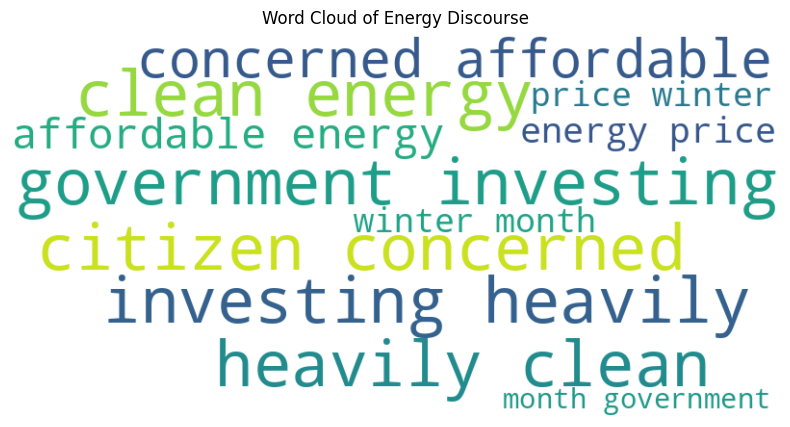

In [10]:
# Creating a Word Cloud
text_corpus = " ".join(lemmatized_tokens * 10) # Multiplying for visual effect in this toy example
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Energy Discourse")
plt.show()

In [11]:
# VADER Sentiment Analysis
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
sentiment_score = sia.polarity_scores(sample_text)
print("Sentiment Analysis Results:")
print(pd.DataFrame([sentiment_score]))

Sentiment Analysis Results:
   neg    neu    pos  compound
0  0.0  0.703  0.297    0.7345


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [12]:
# new data
data = {
    'Speaker': ['MP 1', 'MP 2', 'MP 3', 'MP 4', 'MP 5'],
    'Statement': [
        "We must transition to clean energy to save the planet.",
        "Affordable energy is a fundamental right for our citizens.",
        "Clean energy investments will create thousands of green jobs.",
        "The cost of living crisis requires us to focus on affordable energy.",
        "Our clean energy targets are ambitious but necessary."
    ]
}
df = pd.DataFrame(data)

In [13]:
# occurrences of "clean energy" vs "affordable energy"
df['Mentions_Clean'] = df['Statement'].str.lower().str.contains('clean energy').astype(int)
df['Mentions_Affordable'] = df['Statement'].str.lower().str.contains('affordable energy').astype(int)


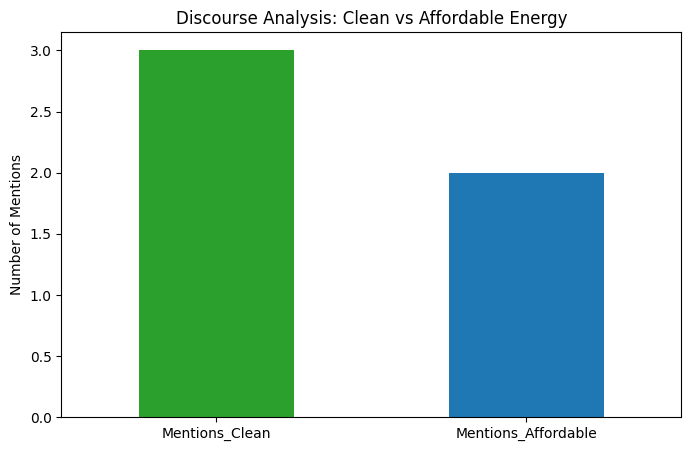

In [14]:
# Visualize the Discourse Gap
summary = df[['Mentions_Clean', 'Mentions_Affordable']].sum()
plt.figure(figsize=(8, 5))
summary.plot(kind='bar', color=['#2ca02c', '#1f77b4'])
plt.title('Discourse Analysis: Clean vs Affordable Energy')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=0)
plt.show()

In [15]:
### tf-idf
corpus = df['Statement'].tolist()
vectorizer = TfidfVectorizer(max_features=10)
X = vectorizer.fit_transform(corpus)

pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

,affordable,clean,energy,of,on,our,planet,requires,the,to
0,0.000000,0.301618,0.214604,0.000000,0.000000,0.000000,0.45037,0.000000,0.363356,0.726712
1,0.652491,0.000000,0.385372,0.000000,0.000000,0.652491,0.00000,0.000000,0.000000,0.000000
2,0.000000,0.581482,0.413729,0.700505,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
3,0.367076,0.000000,0.216801,0.367076,0.454982,0.000000,0.00000,0.454982,0.367076,0.367076
4,0.000000,0.581482,0.413729,0.000000,0.000000,0.700505,0.00000,0.000000,0.000000,0.000000


In [16]:
##  topic modelling============ nmf and lda
nmf = NMF(n_components=2, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_

print("=== NMF Topics ===")
for idx, topic in enumerate(H):
    print(f"Topic {idx+1}: ",
          [vectorizer.get_feature_names_out()[i] 
           for i in topic.argsort()[-5:]])

=== NMF Topics ===
Topic 1:  ['of', 'affordable', 'clean', 'energy', 'our']
Topic 2:  ['clean', 'energy', 'of', 'the', 'to']


In [17]:
# LDA (Latent Dirichlet Allocation)
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)

print("\n=== LDA Topics ===")
for idx, topic in enumerate(lda.components_):
    top_words = topic.argsort()[-5:]
    print(f"Topic {idx+1}: ",
          [vectorizer.get_feature_names_out()[i] for i in top_words])


=== LDA Topics ===
Topic 1:  ['requires', 'on', 'energy', 'our', 'affordable']
Topic 2:  ['our', 'of', 'to', 'energy', 'clean']


In [ ]:
### NER
# python -m spacy download en_core_web_sm # run in prompt
nlp = spacy.load("en_core_web_sm")

doc = nlp(sample_text)
[(ent.text, ent.label_) for ent in doc.ents]

doc2 = nlp("In 2023, the UK government invested £2 billion in renewable energy projects across London and Scotland.")
[(ent.text, ent.label_) for ent in doc2.ents]


In [ ]:
### limitations
sarcasm = "Oh great, another increase in energy prices. Fantastic!"
sia.polarity_scores(sarcasm)